### Scrap notebook for testing and plotting

In [1]:
from astropy.cosmology import Planck18
%env XLA_PYTHON_CLIENT_ALLOCATOR=platform
import astropy.units as u
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
from glob import glob
import lalsimulation as lalsim
import numpy as np
import os.path as op
import sys
import pandas as pd
sys.path.append('../src/')
import weighting
import jax.numpy as jnp
import h5py
import matplotlib.pyplot as plt
from tqdm import tqdm
import scipy
import mock_observations
import intensity_models
from scipy import special
#import re
#import os
from scipy.interpolate import RegularGridInterpolator
import jax
from importlib import reload 
#reload(fisher_snrs)
jax.local_devices()
jax.config.update("jax_enable_x64", True)
from inspect import getfullargspec


env: XLA_PYTHON_CLIENT_ALLOCATOR=platform


/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
population_parameters, cosmo_true = weighting.get_pop_params('pop_configs/mock_GWTC5_evo_mmin4.txt')
log_dN_obj = intensity_models.LogDNDMDQDV
pop_params = {key: population_parameters[key] for key in getfullargspec(log_dN_obj)[0][1:] if key in population_parameters.keys()}
log_dN_func = log_dN_obj(**pop_params)
log_dN_func(6, .5, 4)

Array([-inf], dtype=float64)

In [3]:
import jax
import jax.numpy as jnp


In [4]:
import gc
gc.collect()
h_vals = np.linspace(0.4, 1.0, 10)
true_params={key: population_parameters[key] for key in getfullargspec(log_dN_obj)[0][1:] if key in population_parameters.keys()}
PE_files=[ '../runs/GWTC5_redone2/PE_GWTC5.h5',
          '../runs/GWTC3/PE_GWTC3.h5' ]
sel_files=[ '../runs/GWTC5_redone2/sel_GWTC5.h5', 
           '../runs/GWTC3/sel_GWTC3.h5' ]

In [5]:
pe_samples_mock = pd.read_hdf(PE_files[0], key='samples')#.iloc[0:2000]# 1.5 to 2.5 k on the 1k tests
m1s_det = np.asarray(pe_samples_mock['m1'].to_list())
qs = np.asarray(pe_samples_mock['q'].to_list())#[:, :1000]
dls =  np.asarray(pe_samples_mock['dl'].to_list())
pdraws = np.asarray(pe_samples_mock['pdraw'].to_list())
#pdraws= jnp.nan_to_num(pdraws, neginf=-1e30, posinf=1e30)

sel_samples=pd.read_hdf(sel_files[0], key='true_parameters')
ndraw=sel_samples['ndraw'].iloc[0]
m1s_sel= np.array(sel_samples['m1d'].to_list())
qs_sel=np.array(sel_samples['q'].to_list())
dls_sel=np.array(sel_samples['dl'].to_list())
pdraw_sel=np.array(sel_samples['pdraw_sel'].to_list())


In [6]:
pdraws[np.isinf(pdraws)]

array([], dtype=float64)

In [7]:
sel_samples_4=pd.read_hdf(sel_files[1], key='true_parameters')
ndraw_4=sel_samples_4['ndraw'].iloc[0]
m1s_sel_4= np.array(sel_samples_4['m1d'].to_list())
qs_sel_4=np.array(sel_samples_4['q'].to_list())
dls_sel_4=np.array(sel_samples_4['dl'].to_list())
pdraw_sel_4=np.array(sel_samples_4['pdraw_sel'].to_list())


pe_samples_mock_4 = pd.read_hdf(PE_files[1], key='samples')#.iloc[0:2000]# 1.5 to 2.5 k on the 1k tests
m1s_det_4 = np.asarray(pe_samples_mock_4['m1'].to_list())
qs_4 = np.asarray(pe_samples_mock_4['q'].to_list())#[:, :1000]
dls_4 =  np.asarray(pe_samples_mock_4['dl'].to_list())
pdraws_4 = np.asarray(pe_samples_mock_4['pdraw'].to_list())

In [21]:
pdraws_4[pdraws_4>0]

array([0.94420997, 0.37840758, 0.9600297 , ..., 6.48900896, 6.74516967,
       6.49866892], shape=(58616,))

In [ ]:
pdraws_4[pdraws_4>0]

GWTC5 max:  10.358672342448797
GWTC4 max:  10.733412513827401


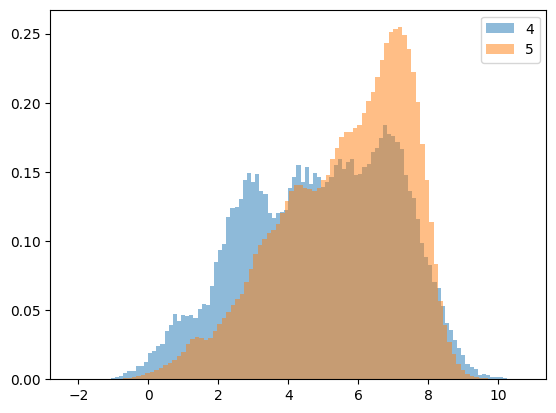

In [22]:
plt.hist((pdraws_4.ravel()), density=True, alpha=.5,bins=100,label='4');
plt.hist((pdraws.ravel()), density=True, alpha=.5,bins=100, label='5');#
#plt.xlim(0,210)
plt.legend()
print('GWTC5 max: ', np.max(pdraws_4.ravel()))
print('GWTC4 max: ', np.max(pdraws.ravel()))

In [9]:
pdraw_sel.ravel()

array([6.37164434e-03, 1.50662283e-03, 4.48316965e-02, ...,
       8.30500034e-05, 5.58288112e-03, 1.60186673e-03], shape=(504666,))

GWTC5 max:  10.358672342448797
GWTC4 max:  10.733412513827401


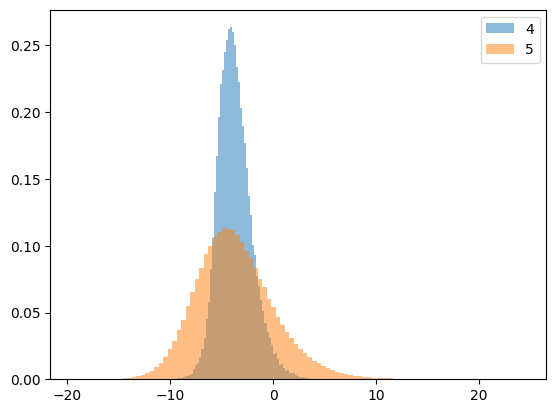

In [10]:
plt.hist(np.log(pdraw_sel_4.ravel()), density=True, alpha=.5,bins=100,label='4');
plt.hist(np.log(pdraw_sel.ravel()), density=True, alpha=.5,bins=100, label='5');#
#plt.xlim(0,210)
plt.legend()
print('GWTC5 max: ', np.max(pdraws_4.ravel()))
print('GWTC4 max: ', np.max(pdraws.ravel()))

GWTC5 min:  0.04717805337464177
GWTC4 min:  0.0753500759601593


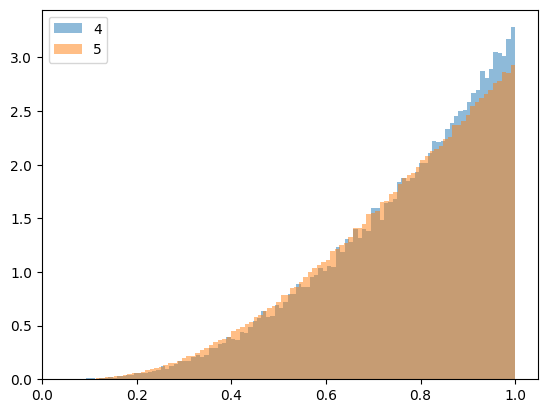

In [11]:
plt.hist(qs_sel_4.ravel(), density=True, alpha=.5,bins=100,label='4');
plt.hist(qs_sel.ravel(), density=True, alpha=.5,bins=100, label='5');#
#plt.xlim(0,210)
plt.legend()
print('GWTC5 min: ', np.min(qs_sel.ravel()))
print('GWTC4 min: ', np.min(qs_sel_4.ravel()))

In [19]:
print(np.max(m1s_sel))
print(np.percentile(m1s_sel, [90, 95, 99, 99.5, 99.9]))
print(np.max(m1s_det.ravel()))
print(np.percentile(m1s_det.ravel(), [90, 95, 99, 99.5, 99.9]))

1125.2460001121017
[145.90816983 177.20335901 255.04745359 295.23192915 422.97488889]
520.9222228672472
[100.0742452  117.68625324 173.40004309 189.39874667 219.8422015 ]


In [28]:
len(m1s_det.ravel()[m1s_det.ravel()>100])/len(m1s_det.ravel())

0.10029115226337448

In [29]:
len(m1s_det_4.ravel()[m1s_det_4.ravel()>100])/len(m1s_det_4.ravel())

0.08059322033898306

GWTC5 min:  6.805803735010599
GWTC4 min:  7.431560252002876
GWTC5 max:  520.9222228672472
GWTC4 max:  290.28281


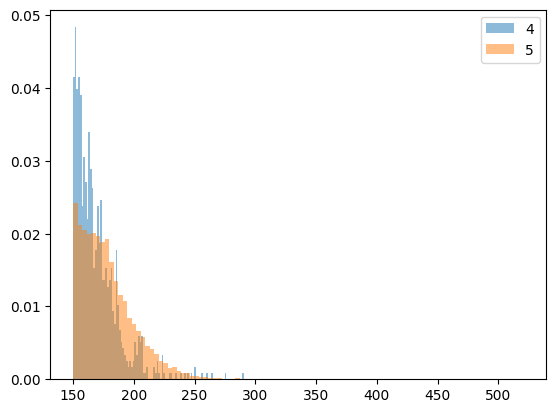

In [27]:
plt.hist(m1s_det_4.ravel()[m1s_det_4.ravel()>150], density=True, alpha=.5,bins=100,label='4');
plt.hist(m1s_det.ravel()[m1s_det.ravel()>150], density=True, alpha=.5,bins=100, label='5');
#plt.xlim(0,250)
plt.legend()
print('GWTC5 min: ', np.min(m1s_det.ravel()))
print('GWTC4 min: ', np.min(m1s_det_4.ravel()))


print('GWTC5 max: ', np.max(m1s_det.ravel()))
print('GWTC4 max: ', np.max(m1s_det_4.ravel()))

In [13]:
zs=cosmo_true.z_of_dL(dls)
m1s_src= m1s_det / (1 + zs)
m2s_src= m1s_src*qs

zs_4=cosmo_true.z_of_dL(dls_4)
m1s_src_4= m1s_det_4 / (1 + zs_4)
m2s_src_4= m1s_src_4*qs_4

GWTC5 min:  2.1587661653102685
GWTC4 min:  2.1978366023270706
GWTC5 max:  141.86682073756324
GWTC4 max:  117.73295638483418


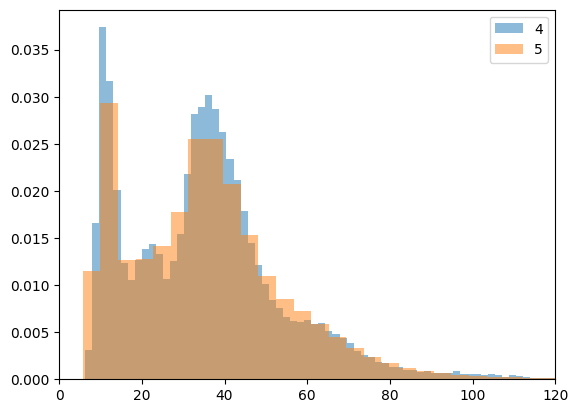

In [14]:
plt.hist(m1s_src_4.ravel(), density=True, alpha=.5,bins=100,label='4');
plt.hist(m1s_src.ravel(), density=True, alpha=.5,bins=100, label='5');
plt.xlim(0,120)
plt.legend()
print('GWTC5 min: ', np.min(m2s_src.ravel()))
print('GWTC4 min: ', np.min(m2s_src_4.ravel()))


print('GWTC5 max: ', np.max(m2s_src.ravel()))
print('GWTC4 max: ', np.max(m2s_src_4.ravel()))

GWTC5 max:  1.8992973354926233
GWTC4  max:  1.8880282898015164


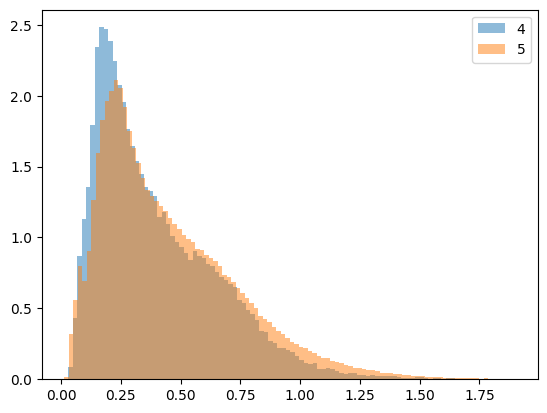

In [15]:
plt.hist(zs_4.ravel(), density=True, alpha=.5,bins=100,label='4');
plt.hist(zs.ravel(), density=True, alpha=.5,bins=100, label='5');
plt.legend()
print('GWTC5 max: ', np.max(zs.ravel()))
print('GWTC4  max: ', np.max(zs_4.ravel()))

In [90]:
def full_loglik_proxy(
    h_val,
    true_params,
    m1s_det, qs, dls, log_pdraw,
    dls_sel, m1s_det_sel, qs_sel, pdraw_sel, Ndraw, keep_mask,
    Om=0.315, w=-1, zmax=6.5
):

    sample = {**true_params, 'h': h_val}

    cosmo = intensity_models.FlatwCDMCosmology(
        sample['h'], Om, w, zmax=zmax
    )
    log_dN = intensity_models.build_population_model(sample)

    # ---------------- event term ----------------

    zs = cosmo.z_of_dL(dls)
    m1s = m1s_det / (1.0 + zs)

    log_wts = (
        log_dN(m1s, qs, zs)
        - log_pdraw
        - 2.0 * jnp.log1p(zs)
        - jnp.log(cosmo.ddL_dz(zs))
        + jnp.log(cosmo.dVCdz(zs))
    )

    # ignore samples with true source-frame m2 < 4
    log_wts = jnp.where(keep_mask, log_wts, -jnp.inf)

    n_keep = jnp.sum(keep_mask, axis=1)
    n_keep = jnp.maximum(n_keep, 1)

    event_ll = jnp.sum(
        jss.logsumexp(log_wts, axis=1)
        - jnp.log(n_keep)
    )

    # ---------------- selection term ----------------
    zs_sel = cosmo.z_of_dL(dls_sel)
    m1s_sel = m1s_det_sel / (1 + zs_sel)

    log_sel_wts = (
        log_dN(m1s_sel, qs_sel, zs_sel)
        - jnp.log(pdraw_sel)
        - 2 * jnp.log1p(zs_sel)
        + jnp.log(cosmo.dVCdz(zs_sel))
        - jnp.log(cosmo.ddL_dz(zs_sel))
    )

    log_mu_sel = jss.logsumexp(log_sel_wts) - jnp.log(Ndraw)

    selection_ll = -m1s_det.shape[0] * log_mu_sel

    return event_ll + selection_ll

In [93]:
def load_true_vals(filename):
    tv = {}

    with open(filename) as f:
        for line in f:
            line = line.strip()

            if line and not line.startswith("#"):
                key, val = line.split("=", 1)
                tv[key.strip()] = float(val.strip())

    # transformed params expected by model
    tv['dkappa'] = tv['kappa'] - tv['lam']
    tv['log_fpl'] = np.log(tv['fpl'])
    tv['dmbhmax'] = tv['mbhmax'] - tv['mpisn']

    # remove unused raw params if desired
    del tv['kappa']
    del tv['fpl']
    del tv['mbhmax']

    return {k: jnp.array(v) for k, v in tv.items()}
#truth_file_name='pop_configs/mock_GWTC5_evo_mmin4_nerr.txt'
#if truth_file_name is not None:
#    print("Loading truth parameters from: ", truth_file_name)
#    truth_params=load_true_vals(truth_file_name)

In [94]:
h_grid = jnp.linspace(0.4, 1.0, 10)
zs=cosmo_true.z_of_dL(dls)
m1s_src= m1s_det / (1 + zs)
m2s_src= m1s_src*qs
mask=np.where(m2s_src>0)[0]

In [95]:
sample = {**true_params, 'h': .674}
cosmo_fid = intensity_models.FlatwCDMCosmology(
        sample['h'],  Om=0.315, w=-1, zmax=6.5)

In [75]:
zs_true = cosmo_fid.z_of_dL(dls)
m1s_src_true = m1s_det / (1.0 + zs_true)
m2s_src_true = m1s_src_true * qs

keep_mask = m2s_src_true > 0
true_params['mbh_min']=3
true_params['delta_m']=1.6

In [96]:
import jax.scipy.special as jss

In [77]:
gc.collect()

44

In [78]:
full_vals_seldm1 = jnp.array([
    full_loglik_proxy(
        float(h),
        true_params,
        m1s_det, qs, dls, pdraws,
        dls_sel, m1s_sel, qs_sel, pdraw_sel, ndraw, keep_mask
    )
    for h in h_grid
])

In [79]:
gc.collect()

12

In [100]:
pe_samples_mock = pd.read_hdf(PE_files[1], key='samples').iloc[6000:7000]# 1.5 to 2.5 k on the 1k tests
m1s_det = np.asarray(pe_samples_mock['m1'].to_list())
qs = np.asarray(pe_samples_mock['q'].to_list())#[:, :1000]
dls =  np.asarray(pe_samples_mock['dl'].to_list())
pdraws = np.asarray(pe_samples_mock['pdraw'].to_list())
pdraws= jnp.nan_to_num(pdraws, neginf=-1e30, posinf=1e30)

sel_samples=pd.read_hdf(sel_files[1], key='true_parameters')
ndraw=sel_samples['ndraw'].iloc[0]
m1s_sel= np.array(sel_samples['m1d'].to_list())
qs_sel=np.array(sel_samples['q'].to_list())
dls_sel=np.array(sel_samples['dl'].to_list())
pdraw_sel=np.array(sel_samples['pdraw_sel'].to_list())


In [101]:
gc.collect()

68

In [102]:
sample = {**true_params, 'h': .674}
cosmo_fid = intensity_models.FlatwCDMCosmology(
        sample['h'],  Om=0.315, w=-1, zmax=6.5)

zs_true = cosmo_fid.z_of_dL(dls)
m1s_src_true = m1s_det / (1.0 + zs_true)
m2s_src_true = m1s_src_true * qs

keep_mask = m2s_src_true > 0
true_params['mbh_min']=3
true_params['delta_m']=1.6

full_vals_seldm2 = jnp.array([
    full_loglik_proxy(
        float(h),
        true_params,
        m1s_det, qs, dls, pdraws,
        dls_sel, m1s_sel, qs_sel, pdraw_sel, ndraw, keep_mask
    )
    for h in h_grid
])

In [ ]:
0 to 2k

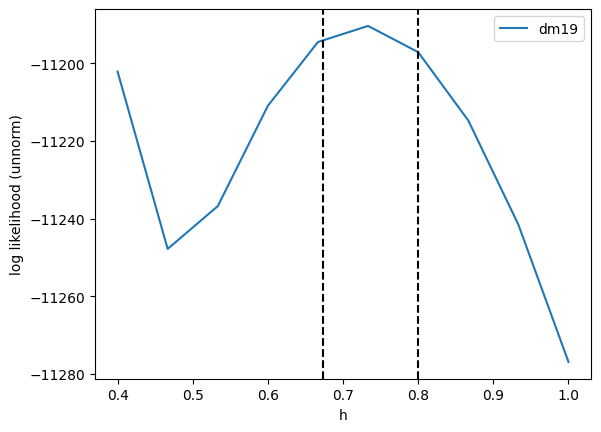

In [105]:
#plt.plot(h_grid, (full_vals_seldm1), label="it 1")
plt.plot(h_grid, (full_vals_seldm2), label="dm19")

plt.axvline(0.674, ls="--", color="k")
plt.axvline(0.8, ls="--", color="k")

plt.legend()
plt.xlabel("h")
plt.ylabel("log likelihood (unnorm)")
plt.show()

In [16]:
gc.collect()

299

In [64]:
data_paths = [#'/mnt/home/ccalvk/ceph/GWTC-3/IGWN-GWTC3p0-v2-GW*_PEDataRelease_mixed_nocosmo.h5',

            #'/mnt/home/ccalvk/ceph/GWTC-2.1/IGWN-GWTC2p1-v2-GW190*_PEDataRelease_mixed_nocosmo.h5',
            '/mnt/home/ccalvk/ceph/GWTC-4/IGWN-GWTC4p0-*-combined_PEDataRelease.hdf5']
files=[]
for path in data_paths:
        print(f'globbing path: {path}')
        files += glob(path)


globbing path: /mnt/home/ccalvk/ceph/GWTC-4/IGWN-GWTC4p0-*-combined_PEDataRelease.hdf5


In [ ]:
inj_file='../runs/mock_GWTC5_evo_mmin/inj_mockGW5.h5'
inj=pd.read_hdf(inj_file, key='true_parameters', start=0, stop=int(2e6))
m1s_inj=inj['m1']

sel_file='../runs/mock_GWTC5_evo_mmin/sel_mockGW5_evo.h5'
sel_samps=pd.read_hdf(sel_file, key='true_parameters')
m1s_sel=sel_samps['m1']

mask_low = (m1s_inj > 1.5) & (m1s_inj < 5)
mask_low_det=(m1s_sel>1.5) & (m1s_sel<5)

print(f"Injections in 1.5-5: {np.sum(mask_low)} / {len(m1s_inj)} = ", np.sum(mask_low)/len(m1s_inj))
print(f"Detection fraction: {np.sum(mask_low_det)} / {len(m1s_sel)} = ", np.sum(mask_low_det)/len(m1s_sel))

Injections in 1.5-5: 23259 / 2000000 =  0.0116295
Detection fraction: 43465 / 100496 =  0.43250477630950485


In [19]:
mpdf=scipy.stats.powerlaw(.5, loc=.4, scale=2500)
rng = np.random.default_rng()
m=mpdf.ppf(rng.uniform(low=0, high=1, size=10000))

In [ ]:
grid_file='snr_grid_aplus.npz'
grid=np.load(grid_file)
m1_grid  = grid["m1_grid"]
q_grid   = grid["q_grid"]
snr_grid = grid["snr_grid"]
dL_fid   = float(grid["dL_fid"])
log_snr_interp = RegularGridInterpolator((m1_grid, q_grid), np.log(snr_grid), bounds_error=False, fill_value=-np.inf)



/tmp/ipykernel_2637405/2473520272.py:7: RuntimeWarning: divide by zero encountered in log
  log_snr_interp = RegularGridInterpolator((m1_grid, q_grid), np.log(snr_grid), bounds_error=False, fill_value=-np.inf)


### Errors

In [14]:
def get_X_logmc(M, SNR, sigma_M):
    """
    Take chirp mass, SNR, and upper and lower bounds on chirp mass.
    Propogate those bounds to log chirp mass bounds
    solve for the linear factor we would use to go from SNR to sigma_log_mc

    Also works for log chirp mass!
    """
    sigma_M=jnp.array(sigma_M)
    log_mc=jnp.log(M)
    sigma_log_mc=np.mean(sigma_M/M) #propogate error and collapse to symmetric errors 
    return SNR*sigma_log_mc  #sigma_log_mc= X/SNR

def get_X_q(SNR, sigma_q):
    """
    solve for the linear factor we would use to go from SNR to sigma_q
    This is old, we now use log_q error
    """
    sigma_q=np.mean(sigma_q) #collapse to symmetric
    return SNR*sigma_q #sigma_q= X/SNR


In [99]:
# Event data: (SNR, M, [lower_error, upper_error])
# all 35 events here: https://gwosc.org/eventapi/html/GWTC-3-confident/
events = [(4.5, 15.0, [29.5, 4.0]),
    (10.3, 8.75, [0.62, 0.55]),
    (17.8, 6.6, [2.4, 2.0]),
    (4.7, 34, [44, 18]),
    (7.8, 17.5, [3.5, 3.0]),
    (10.8, 23.4, [4.7, 3.0]),
    (12.5, 14.2, [1.5, 1.4]),
    (20.0, 31.1, [3.3, 2.7]),
    (8.5, 28.2, [7.3, 5.1]),
    (7.2, 62, [23, 15]),
    (10.7, 27.6, [5.6, 3.8]),
    (8.1, 32.9, [9.3, 8.5]),
    (8.4, 6.56, [0.38, 0.40]),
    (9.6, 26.7, [6.0, 4.2]),
    (7.4, 19.8, [10.5, 5.2]),
    (10.8, 27.7, [3.7, 3.1]),
    (10.8, 7.49, [0.24, 0.2]),
    (26.8, 27.2, [2.1, 2.3]),
    (10.6, 32.0, [7.5, 5.5]),
    (11.3, 2.43, [0.05, 0.07]),
    (19.8, 27.4, [2.6, 2.1]),
    (10.4, 36.5, [8.2, 5.6]),
    (12.5, 33.8, [7.1, 5.0]),
    (9.1, 4.31, [0.12, 0.17]),
    (18.6, 8.33, [0.22, 0.19]),
    (11.2, 18.4, [2.2, 1.7]),
    (17.4, 8.56, [0.41, 0.28]),
    (8.9, 19.8, [3.6, 3.2]),
    (13.1, 7.31, [0.43, 0.28]),
    (9.2, 29.9, [11.7, 9.1]),
    (8.3, 8.65, [0.95, 0.71]),
    (7.9, 10.7, [1.1, 1.0]),
    (17.3, 47.5, [9.6, 7.5]),
    (9.7, 7.82, [0.61, 0.45]),
    (8.9, 8.34, [0.66, 0.57])]

Xs_1 = [get_X_logmc(M, SNR, errors) for SNR, M, errors in events]

print("Mean X:", np.mean(Xs_1))
print("Std X:", np.std(Xs_1))

Mean X: 1.767974784089777
Std X: 1.3006138540035586


In [100]:
events_q= [(4.5, 0.3, [0.7, 0.7]),
(10.3, 0.6, [0.4, 0.4]),
(17.8, 0.8, [0.2, 0.2]),
(4.7, 0.4, [0.8, 0.8]),
(7.8, 0.5, [0.3, 0.3]),
(10.8, 0.5, [0.2, 0.2]),
(12.5, 0.7, [0.2, 0.2]),
(20.0, 0.8, [0.2, 0.2]),
(8.5, 0.7, [0.3, 0.3]),
(7.2, 0.7, [0.4, 0.4]),
(10.7, 0.7, [0.3, 0.3]),
(8.1, 0.6, [0.4, 0.4]),
(8.4, 0.117427385892116, [0.0347841574263123, 0.0347841574263123]),
(9.6, 0.8, [0.3, 0.3]),
(7.4, 0.2, [0.3, 0.3]),
(10.8, 0.7, [0.2, 0.2]),
(10.8, 0.7, [0.2, 0.2]),
(26.8, 0.8, [0.2, 0.2]),
(10.6, 0.8, [0.3, 0.3]),
(11.3, 0.244067796610169, [0.133543137064012, 0.133543137064012]),
(19.8, 0.8, [0.2, 0.2]),
(10.4, 0.7, [0.3, 0.3]),
(12.5, 0.8, [0.3, 0.3]),
(9.1, 0.037620578778135, [0.00367611097618323, 0.00367611097618323]),
(18.6, 0.6, [0.2, 0.2]),
(11.2, 0.7, [0.2, 0.2]),
(17.4, 0.7, [0.2, 0.2]),
(8.9, 0.7, [0.3, 0.3]),
(13.1, 0.6, [0.2, 0.2]),
(9.2, 0.5, [0.4, 0.4]),
(8.3, 0.7, [0.3, 0.3]),
(7.9, 0.2, [0.1, 0.1]),
(17.3, 0.7, [0.2, 0.2]),
(9.7, 0.7, [0.2, 0.2]),
(8.9, 0.7, [0.3, 0.3])]



Xs_q = [get_X_q(SNR, errors) for SNR, _, errors in events_q]
SNRS=[]
for i in range(len(events_q)):
    SNRS.append(events_q[i][0])
print("Mean X:", np.mean(Xs_q)) 
print("Std X:", np.std(Xs_q))

Mean X: 2.7958479137453605
Std X: 1.0628760418098722


### LIGO way

In [ ]:
import sys
sys.path.append('../src/')
import weighting
import h5py
from astropy.cosmology import Planck18
import jax.scipy.special as jss
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
import pandas as pd
import numpy as np

/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
reload(weighting)

NameError: name 'reload' is not defined

In [68]:
#('/home/reed.essick/rates+pop/o3-sensitivity-estimates/LIGO-T2100113-v11/endo3_bbhpop-LIGO-T2100113-v11.hdf5', nsamp=None, desired_pop_wt=None)
m1, q, z, a1, a2, cos_tilt1, cos_tilt2, pdraw, ndraw = weighting.sel_samples_mock('../endo3_bbhpop-LIGO-T2100113-v12.hdf5', 
                                                                                  detectors=detectors, SNR=8, 
                                                                                  sensitivity='o3_PSD',  SNR_load=True,
                                                                                  SNR_write=False,  SNR_file='LIGO_SNR_1222.txt')
df = pd.DataFrame({'m1': m1, 'q': q, 'z': z, 'a1': a1, 'a2':a2, 'cos_tilt_1': cos_tilt1, 'cos_tilt_2': cos_tilt2, 'pdraw_m1sqz': pdraw, 'ndraw': ndraw}) 

In [70]:
df['dm1sz_dm1ddl'] = 1/ ((1+df['z'].values))*cosmo.ddL_dz(df['z'].values)
# weighting.dm1sz_dm1ddl(df['z'])#gives us factor to go soruce to detector frame mass, and z to dL in prior
df.to_hdf('./selection_samples_o3_1230.h5', 'samples')

/tmp/ipykernel_1659843/2770026045.py:3: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  df.to_hdf('./selection_samples_o3_1230.h5', 'samples')


In [3]:
file='../runs/mixture-semi_o1_o2-real_o3_o4a_o4b-cartesian_spins_20260410130052UTC-clipped.hdf'
f = pd.read_hdf(file, key='events')
len(f)

/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'o4a_cwb-bbh_far'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'o4b_cwb-bbh_far'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'o4a_cwb-bbh_p_astro'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``

2504653

In [4]:
sel_files=[ '../runs/GWTC5_redone/sel_GWTC5.h5',  ]
sel_samples=pd.read_hdf(sel_files[0], key='true_parameters')
len(sel_samples)

504666

In [13]:
#('/home/reed.essick/rates+pop/o3-sensitivity-estimates/LIGO-T2100113-v11/endo3_bbhpop-LIGO-T2100113-v11.hdf5', nsamp=None, desired_pop_wt=None)
(m1, q, z, a1, a2, cos_tilt1, cos_tilt2, pdraw, ndraw)=weighting.extract_selection_samples(file,nsamp=None, desired_pop_wt=None)
df = pd.DataFrame({'m1': m1, 'q': q, 'z': z, 'a1': a1, 'a2':a2, 'cos_tilt_1': cos_tilt1, 'cos_tilt_2': cos_tilt2, 'pdraw_m1sqz': pdraw, 'ndraw': ndraw}) 

/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'o4a_cwb-bbh_far'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'o4b_cwb-bbh_far'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'o4a_cwb-bbh_p_astro'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``

In [11]:
len(df)

482163

In [14]:
len(df)

504666

In [15]:
504666/482163

1.0466709390807674